## Problema

Se tiene una flecha que será ensamblada en un cojinete como se muestra en la figura.

![Figura de una flecha con diámetro x1 y cojinete con diámetro x2](Flecha%20y%20cojinete.png)

Si **$x_1$** sigue una distribución normal con media $1.5$ y variancia $0.0016$ y si **$x_2$** sigue esta misma distibución con media $1.48$ y varianza $0.0009$, determinar:

1.  La probabilidad de que haya interferencia
2. El número de veces necesario que es necesario simular el experimento, si se quiere que la probabilidad de interferencia estimada difiera de su valor verdadero en menos de $0.01$, con un nivel de seguridad de $95\%$

## Simulación Analítica

### Probabilidad de interferencia

Para conocer la probabilidadde interferencia, sea que:

 * $x_1$=diámetro de la flecha $\sim N(\mu=1.5,\sigma^2=0.0016)$
 * $x_2$=diámetro del cojinete $\sim N(\mu=1.48,\sigma^2=0.0009)$

La interferencia ocurre cuando la flecha es más grande que el cojinete $x_{1}>x_{2}$. Definimos $D=x_{1}-x_{2}$ por independencia}:

$$
D\sim N(\mu_{D}=\mu_{1}-\mu_{2}=0.02,\sigma^2_{D}=\sigma^2_{1}+\sigma^2_{2}=0.0016+0.0009=0.0024)
$$

$$
\sigma_{D}=\sqrt{0.0025}=0.05
$$

La probabilidad de interferencia es:

$$
P(x_{1}>x_{2})=P(D>0)=1-\Phi\left(\frac{0-0.02}{0.05}\right)=1-\Phi(-0.04)=\Phi(0.04)
$$

Siendo entences la probabilidad exacta de probabilidad es $\Phi(0.4)\approx0.6654$
### Número de simulaciones

Por el teorema cental del límite a un $n$ grande, $\hat{p}$ es aproximadamente normal:
 $$ 
 \hat{p}\approx N\left(p,\frac{p(1-p)}{n}\right)
 $$

 
Entonces:

$$
P(|\hat{p}-p|\epsilon)\approx 2\Phi\left(\frac{\epsilon}{\sqrt{\frac{p(1-p)}{n}}}\right)-1
$$

Siendo $p$ la probabilidad que buscamos evaluar de la interferencia, y $\epsilon$, el máximo que no queremos que difiera la probabilidad simulada con la obtenida analíticament, siendo $\epsilon=0.01$. Fijamos esta probabilidad en $0.95$, dado que queremos tener un nivel de seguridad de $95\%$:
$$
2\Phi\left(\frac{\epsilon}{\sqrt{\frac{p(1-p)}{n}}}\right)-1=0.95
\Rightarrow \Phi\left(\frac{\epsilon}{\sqrt{\frac{p(1-p)}{n}}}\right)=0.975
$$

El cuantil $Z_{0.025}=\Phi^{-1}(0.975)=1.96$.Luego:
$$
\frac{\epsilon}{\sqrt{\frac{p(1-p)}{n}}}=1.96 \Rightarrow \sqrt{n}=\frac{1.96\sqrt{p(1-p)}}{\epsilon}
$$
Elevando al cuadrado:
    $$
    n=\frac{(1.96)^2 p(1-p)}{\epsilon^2}
    $$

Evaluando en un caso conservador con máxima varianza: $p=0.5$
$$
    n=\frac{(1.96)^2 0.25}{0.0001}=\frac{.9604}{0.0001}=9604
$$

Siendo que sera que para $p=0.5$, $n\approx9600$.


## Simulación de la probabilidad de interferencia
Buscamos conocer a través de simulación la probabilidad de la interferencia entre las dos variables, $x_1$ y $x_2$

In [15]:
# Librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from multiprocessing import Pool
import time

In [12]:
#Distribución normal por método de las 12 uniformes
def normal_12_uniforms(mu, sigma, size=1):
    u = np.random.uniform(0, 1, (size, 12))
    suma = np.sum(u, axis=1)
    return mu + sigma * (suma - 6)

Ejecutando simulación de estabilización...


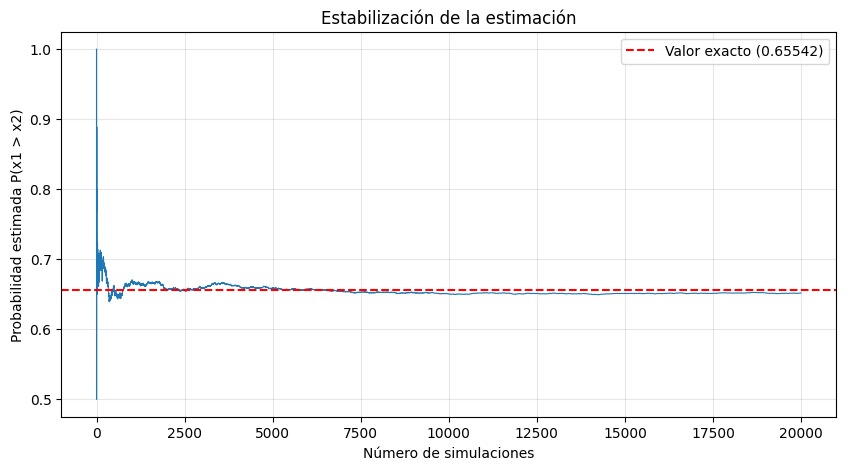

In [13]:
# ============================================================
# 1. Identificar las variables aleatorias
# ============================================================
# x1: diámetro flecha, x2: diámetro cojinete

# ============================================================
# 2. Distribuciones de probabilidad
# ============================================================
mu1, sigma1 = 1.5, 0.04   # varianza 0.0016
mu2, sigma2 = 1.48, 0.03  # varianza 0.0009

# ============================================================
# 3. Modelar las variables aleatorias
# ============================================================
def generar_mediciones(n=1):
    """Genera n pares (x1, x2) independientes."""
    x1 = normal_12_uniforms(mu1, sigma1, n)
    x2 = normal_12_uniforms(mu2, sigma2, n)
    return x1, x2

# ============================================================
# 4. Modelo del sistema y objetivos
# ============================================================
# Interferencia si x1 > x2
# Objetivo: estimar p = P(x1 > x2)

# ============================================================
# 5. Diseño del experimento (determinar n_trials)
# ============================================================
# Realizamos una simulación de estabilización con hasta 20000 iteraciones
N_max = 20000
resultados = np.zeros(N_max)

print("Ejecutando simulación de estabilización...")
for i in range(N_max):
    x1, x2 = generar_mediciones(1)
    resultados[i] = 1 if x1 > x2 else 0

# ============================================================
# 6. Repetir el experimento n veces (ya realizado)
# ============================================================

# ============================================================
# 7. Gráfica de estabilización
# ============================================================
acum_mean = np.cumsum(resultados) / np.arange(1, N_max+1)

plt.figure(figsize=(10,5))
plt.plot(acum_mean, linewidth=0.8)
plt.xlabel('Número de simulaciones')
plt.ylabel('Probabilidad estimada P(x1 > x2)')
plt.title('Estabilización de la estimación')
plt.grid(alpha=0.3)
plt.axhline(y=0.65542, color='r', linestyle='--', label='Valor exacto (0.65542)')
plt.legend()
plt.show()



In [23]:
# A partir de la gráfica, con n ≈ 5000 la estimación ya es estable.
# Elegimos n_trials = 10000 para cada réplica (mayor que el mínimo necesario)
n_trials = 10000
print(f"Número de experimentos por réplica seleccionado: {n_trials}")

# ============================================================
# 8. Replicar el modelo (M réplicas, en paralelo)
# ============================================================
def una_replica(n):
    """Ejecuta una réplica con n experimentos, devuelve estimación de p."""
    x1, x2 = generar_mediciones(n)
    prob = np.mean(x1 > x2)
    return prob

M = 1000   # número de réplicas
print(f"\nEjecutando {M} réplicas con {n_trials} experimentos cada una...")
inicio = time.time()

with Pool() as pool:
    estimaciones = pool.map(una_replica, [n_trials] * M)

duracion = time.time() - inicio
print(f"Tiempo total (paralelo): {duracion:.2f} segundos")

# ============================================================
# 9. Calcular la probabilidad buscada
# ============================================================
p_estimada = np.mean(estimaciones)
std_hat = np.std(estimaciones)
var_hat = np.var(estimaciones)
print(f"\nProbabilidad estimada (media de {M} réplicas): {p_estimada:.6f}")
print(f"La desviación estándar de las simulaciones (con {M} simulaciones): {std_hat:.6f}")
print(f"La varianza de las simulaciones (con {M} simulaciones): {var_hat:.6f}")

Número de experimentos por réplica seleccionado: 10000

Ejecutando 1000 réplicas con 10000 experimentos cada una...


Tiempo total (paralelo): 3.71 segundos

Probabilidad estimada (media de 1000 réplicas): 0.654646
La desviación estándar de las simulaciones (con 1000 simulaciones): 0.004929
La varianza de las simulaciones (con 1000 simulaciones): 0.000024


Intervalo de confianza del 95%: (0.6453, 0.6640)


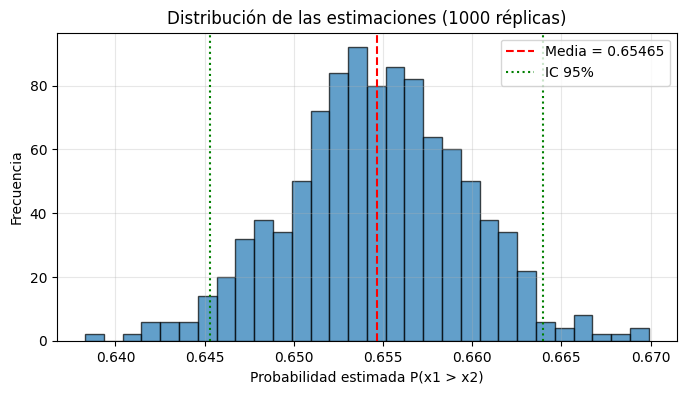


Error absoluto de la estimación (respecto al valor exacto): 0.000776
El error es menor que 0.01


In [24]:
# ============================================================
# 10. Intervalo de confianza del 95%
# ============================================================
# Método basado en error estándar
z = 1.96
error = z * np.sqrt(p_estimada * (1 - p_estimada) / n_trials)
ic_inf = p_estimada - error
ic_sup = p_estimada + error
print(f"Intervalo de confianza del 95%: ({ic_inf:.4f}, {ic_sup:.4f})")

# Histograma de las estimaciones de cada réplica
plt.figure(figsize=(8,4))
plt.hist(estimaciones, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(p_estimada, color='red', linestyle='--', label=f'Media = {p_estimada:.5f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95%')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.xlabel('Probabilidad estimada P(x1 > x2)')
plt.ylabel('Frecuencia')
plt.title(f'Distribución de las estimaciones ({M} réplicas)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Verificación del error: comparación con el valor teórico
error_abs = abs(p_estimada - 0.655421741)
print(f"\nError absoluto de la estimación (respecto al valor exacto): {error_abs:.6f}")
print(f"El error es {'menor' if error_abs < 0.01 else 'mayor'} que 0.01")

## Simulación del número del tamaño de muestra
Por simulación buscamo conocer el valor que podríamos obtener del tamaño de veces a realizar la simulación para tener una diferencia menor de $0.01$ de la interferencia de la probabilidad obtenida con una confianza del $95\%$

In [27]:
# Parámetros
epsilon = 0.01   # error máximo deseado
confianza = 0.95
z = stats.norm.ppf((1 + confianza)/2)  # 1.96

# Simulación adaptativa
resultados = []   # lista de indicadores (1 si interferencia)
n_actual = 0
error_actual = float('inf')
n_max = 50000     # límite por seguridad

print("Iniciando simulación adaptativa...")
while error_actual > epsilon and n_actual < n_max:
    # Agregar batch de 100 experimentos (para eficiencia)
    batch = 100
    x1 = normal_12_uniforms(mu1, sigma1, batch)
    x2 = normal_12_uniforms(mu2, sigma2, batch)
    resultados.extend((x1 > x2).astype(int))
    n_actual = len(resultados)
    
    if n_actual >= 30:   # para poder calcular IC
        p_hat = np.mean(resultados)
        sem = np.sqrt(p_hat * (1 - p_hat) / n_actual)
        error_actual = z * sem   # semi-ancho del IC 95%
        
        if n_actual % 1000 == 0:
            print(f"n={n_actual}, p≈{p_hat:.5f}, error_actual={error_actual:.5f}")

print(f"\nSe requirieron {n_actual} experimentos")
print(f"Probabilidad estimada: {p_hat:.6f}")
print(f"Error absoluto respecto al valor verdadero (0.65542): {abs(p_hat-0.65542):.6f}")

Iniciando simulación adaptativa...
n=1000, p≈0.65100, error_actual=0.02954
n=2000, p≈0.66250, error_actual=0.02072
n=3000, p≈0.65767, error_actual=0.01698
n=4000, p≈0.65650, error_actual=0.01472
n=5000, p≈0.65300, error_actual=0.01319
n=6000, p≈0.65150, error_actual=0.01206
n=7000, p≈0.64871, error_actual=0.01118
n=8000, p≈0.65100, error_actual=0.01044

Se requirieron 8800 experimentos
Probabilidad estimada: 0.652614
Error absoluto respecto al valor verdadero (0.65542): 0.002806
